In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("phase 2 data.csv")
df

,Index,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,...,College 1 year to 3 years (Some college or technical school),College 4 years or more (College graduate),"Earns Less than $10,000 Annually","Earns $10,000-$14,999 Annually","Earns $15,000-$19,999 Annually","Earns $20,000-$24,999 Annually","Earns $25,000-$34,999 Annually","Earns $35,000-$49,999 Annually","Earns $50,000-$74,999 Annually","Earns More than $75,000 Annually"
0,0,0.0,1.0,1.0,1.0,1.316755,1.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,0
1,1,0.0,0.0,0.0,0.0,-0.312639,1.0,0.0,0.0,1.0,...,0,1,1,0,0,0,0,0,0,0
2,2,0.0,1.0,1.0,1.0,0.140916,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
3,3,0.0,1.0,0.0,1.0,0.000000,0.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,1,0,0
4,4,0.0,1.0,1.0,1.0,-0.486739,0.0,0.0,0.0,1.0,...,1,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,253675,0.0,1.0,1.0,1.0,1.633059,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,0,1,0
253676,253676,2.0,1.0,1.0,1.0,-1.893247,0.0,0.0,0.0,0.0,...,0,0,0,0,0,1,0,0,0,0
253677,253677,0.0,0.0,0.0,1.0,0.140916,0.0,0.0,0.0,1.0,...,1,0,0,1,0,0,0,0,0,0
253678,253678,0.0,1.0,0.0,1.0,-0.674597,0.0,0.0,0.0,0.0,...,1,0,1,0,0,0,0,0,0,0


In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

X = df.drop(columns=["Diabetes_012","Index"])
X

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,College 1 year to 3 years (Some college or technical school),College 4 years or more (College graduate),"Earns Less than $10,000 Annually","Earns $10,000-$14,999 Annually","Earns $15,000-$19,999 Annually","Earns $20,000-$24,999 Annually","Earns $25,000-$34,999 Annually","Earns $35,000-$49,999 Annually","Earns $50,000-$74,999 Annually","Earns More than $75,000 Annually"
0,1.0,1.0,1.0,1.316755,1.0,0.0,0.0,0.0,0.0,1.0,...,0,0,0,0,1,0,0,0,0,0
1,0.0,0.0,0.0,-0.312639,1.0,0.0,0.0,1.0,0.0,0.0,...,0,1,1,0,0,0,0,0,0,0
2,1.0,1.0,1.0,0.140916,0.0,0.0,0.0,0.0,1.0,0.0,...,0,0,0,0,0,0,0,0,0,1
3,1.0,0.0,1.0,0.000000,0.0,0.0,0.0,1.0,1.0,1.0,...,0,0,0,0,0,0,0,1,0,0
4,1.0,1.0,1.0,-0.486739,0.0,0.0,0.0,1.0,1.0,1.0,...,1,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,1.0,1.0,1.0,1.633059,0.0,0.0,0.0,0.0,1.0,1.0,...,0,1,0,0,0,0,0,0,1,0
253676,1.0,1.0,1.0,-1.893247,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,1,0,0,0,0
253677,0.0,0.0,1.0,0.140916,0.0,0.0,0.0,1.0,1.0,0.0,...,1,0,0,1,0,0,0,0,0,0
253678,1.0,0.0,1.0,-0.674597,0.0,0.0,0.0,0.0,1.0,1.0,...,1,0,1,0,0,0,0,0,0,0


In [4]:
y = df["Diabetes_012"]
DT = DecisionTreeClassifier()
y

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
253675    0.0
253676    2.0
253677    0.0
253678    0.0
253679    2.0
Name: Diabetes_012, Length: 253680, dtype: float64

In [5]:
Precision = []
Recall = []
F1 = []
Accuracy = []
AUC = []
for train_indexes, test_indexes in KFold(n_splits=10, shuffle=True).split(X):
    X_train, X_test = X.iloc[train_indexes], X.iloc[test_indexes]
    y_train, y_test = y.iloc[train_indexes], y.iloc[test_indexes]
    DT.fit(X_train, y_train)
    y_pred = DT.predict(X_test)
    y_pred_proba = DT.predict_proba(X_test)
    Precision.append(precision_score(y_test, y_pred, average=None))
    Recall.append(recall_score(y_test, y_pred, average=None))
    F1.append(f1_score(y_test, y_pred, average=None))
    Accuracy.append(accuracy_score(y_test, y_pred))
    AUC.append(roc_auc_score(y_test, y_pred_proba, multi_class="ovr"))

Precision, Recall, F1, Accuracy, AUC

([array([0.87678309, 0.03461538, 0.2852949 ]),
  array([0.87544282, 0.0293578 , 0.28778751]),
  array([0.87579047, 0.03780718, 0.29816388]),
  array([0.87556883, 0.02777778, 0.29635584]),
  array([0.87161069, 0.03911565, 0.290314  ]),
  array([0.8746866 , 0.03345725, 0.28908155]),
  array([0.87403184, 0.03467153, 0.30754967]),
  array([0.87622706, 0.03969754, 0.30890192]),
  array([0.87324078, 0.02819237, 0.30538441]),
  array([0.87581668, 0.01414141, 0.29645428])],
 [array([0.86263813, 0.03991131, 0.30806916]),
  array([0.86506418, 0.03579418, 0.30062929]),
  array([0.86707471, 0.04357298, 0.31032516]),
  array([0.86450435, 0.03282276, 0.31198872]),
  array([0.85962937, 0.05021834, 0.30347705]),
  array([0.86442263, 0.03797468, 0.30450913]),
  array([0.86356808, 0.03838384, 0.32493703]),
  array([0.86486613, 0.04565217, 0.3270316 ]),
  array([0.86265853, 0.03609342, 0.31605212]),
  array([0.86431809, 0.01525054, 0.31717056])],
 [array([0.8696531 , 0.03707518, 0.29624498]),
  array([0.

In [6]:
Precision = np.array(Precision)
Recall = np.array(Recall)
F1 = np.array(F1)
Accuracy = np.array(Accuracy)
AUC = np.array(AUC)

In [7]:
Diabetes_0_Precision = Precision[:, 0].mean()
Diabetes_1_Precision = Precision[:, 1].mean()
Diabetes_2_Precision = Precision[:, 2].mean()
Diabetes_0_Recall = Recall[:, 0].mean()
Diabetes_1_Recall = Recall[:, 1].mean()
Diabetes_2_Recall = Recall[:, 2].mean()
Diabetes_0_F1 = F1[:, 0].mean()
Diabetes_1_F1 = F1[:, 1].mean()
Diabetes_2_F1 = F1[:, 2].mean()
Diabetes_Accuracy = Accuracy.mean()
Diabetes_AUC = AUC.mean()
Diabetes_0_Precision, Diabetes_1_Precision, Diabetes_2_Precision, Diabetes_0_Recall, Diabetes_1_Recall, Diabetes_2_Recall, Diabetes_0_F1, Diabetes_1_F1, Diabetes_2_F1, Diabetes_Accuracy, Diabetes_AUC

(0.8749198856636229,
 0.031883390024943906,
 0.296528796072128,
 0.8638744183252189,
 0.037567423288410604,
 0.31241898281783137,
 0.8693615526483797,
 0.034469243540041675,
 0.3042554256134659,
 0.7719607379375591,
 0.567746594177139)

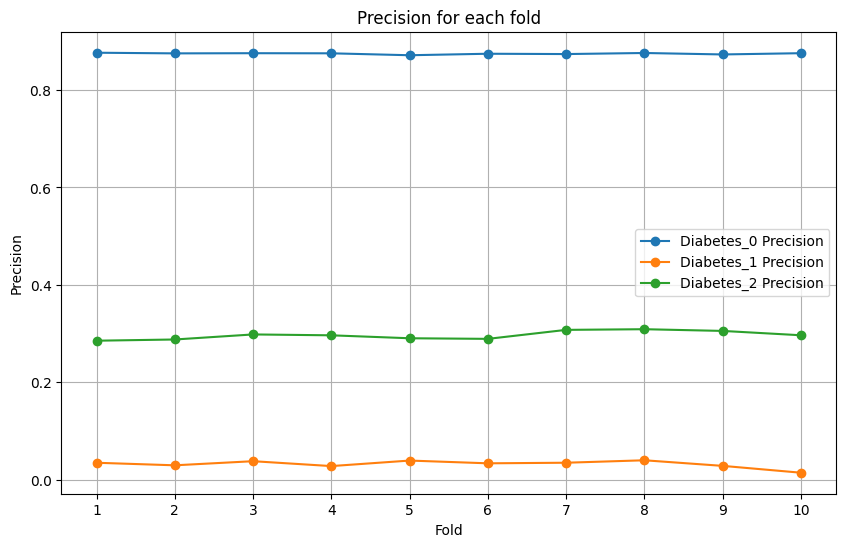

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), Precision[:, 0], marker='o', label='Diabetes_0 Precision')
plt.plot(range(1, 11), Precision[:, 1], marker='o', label='Diabetes_1 Precision')
plt.plot(range(1, 11), Precision[:, 2], marker='o', label='Diabetes_2 Precision')
plt.title('Precision for each fold')
plt.xlabel('Fold')
plt.ylabel('Precision')
plt.xticks(range(1, 11))
plt.legend()
plt.grid()
plt.show() 

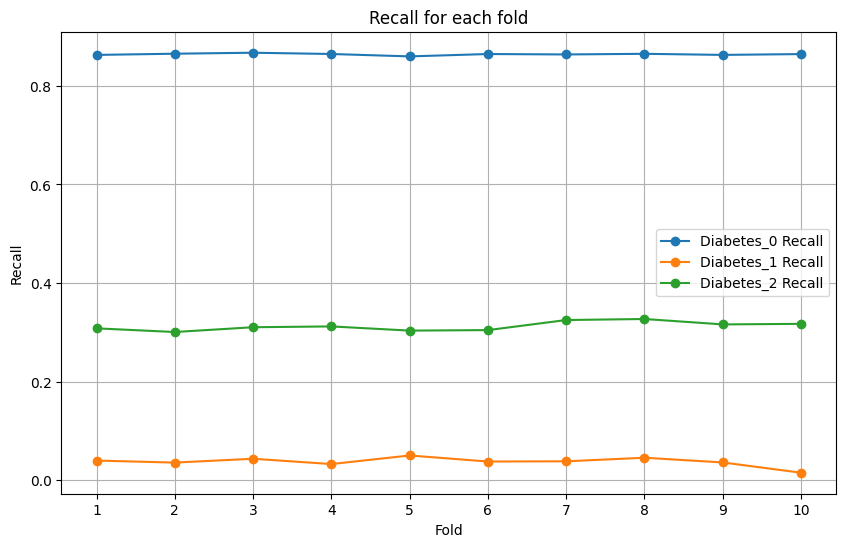

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(range(1,11), Recall[:, 0], marker='o', label='Diabetes_0 Recall')
plt.plot(range(1,11), Recall[:, 1], marker='o', label="Diabetes_1 Recall")
plt.plot(range(1,11), Recall[:, 2], marker='o', label="Diabetes_2 Recall")
plt.title("Recall for each fold")
plt.xlabel("Fold")
plt.ylabel("Recall")
plt.xticks(range(1,11))
plt.legend()
plt.grid()
plt.show()

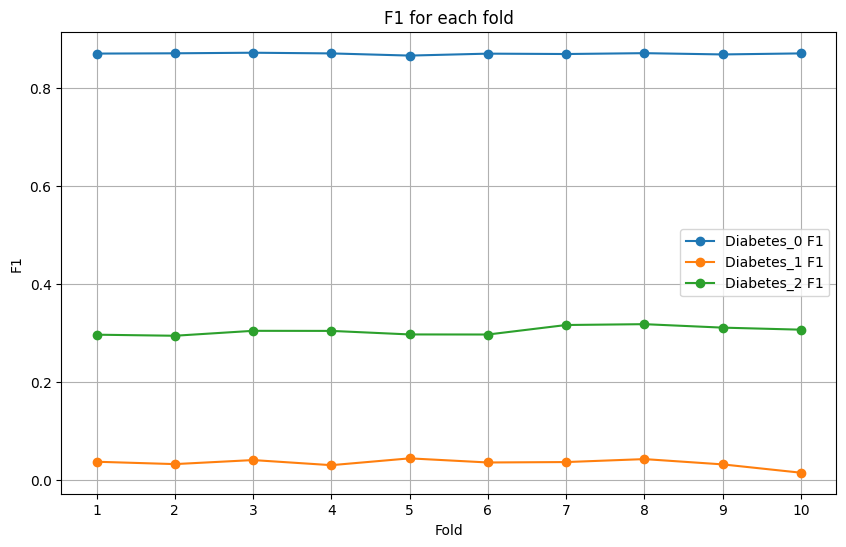

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(range(1,11), F1[:, 0], marker='o', label='Diabetes_0 F1')
plt.plot(range(1,11), F1[:, 1], marker='o', label='Diabetes_1 F1')
plt.plot(range(1,11), F1[:, 2], marker='o', label='Diabetes_2 F1')
plt.title("F1 for each fold")
plt.xlabel("Fold")
plt.ylabel("F1")
plt.xticks(range(1,11))
plt.legend()
plt.grid()
plt.show()

In [ ]:
Diabetes_Dict = {
    "Diabetes_0_Precision": Diabetes_0_Precision,
    "Diabetes_1_Precision": Diabetes_1_Precision,
    "Diabetes_2_Precision": Diabetes_2_Precision,
    "Diabetes_0_Recall": Diabetes_0_Recall,
    "Diabetes_1_Recall": Diabetes_1_Recall,
    "Diabetes_2_Recall": Diabetes_2_Recall,
    "Diabetes_0_F1": Diabetes_0_F1,
    "Diabetes_1_F1": Diabetes_1_F1,
    "Diabetes_2_F1": Diabetes_2_F1,
    "Diabetes_Accuracy": Diabetes_Accuracy,
    "Diabetes_AUC": Diabetes_AUC
}

Diabetes_Frame = pd.DataFrame(Diabetes_Dict, index=[0])
Diabetes_Frame.to_csv("Diabetes_Results_MLP.csv", index=False)
Diabetes_Frame

,Diabetes_0_Precision,Diabetes_1_Precision,Diabetes_2_Precision,Diabetes_0_Recall,Diabetes_1_Recall,Diabetes_2_Recall,Diabetes_0_F1,Diabetes_1_F1,Diabetes_2_F1,Diabetes_Accuracy,Diabetes_AUC
0,0.87492,0.031883,0.296529,0.863874,0.037567,0.312419,0.869362,0.034469,0.304255,0.771961,0.567747


: 